In [37]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [38]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\02_tiny_llm\\model'

In [39]:
import warnings
warnings.filterwarnings("ignore")
from data.dataset import GPTDataset, create_dataloader
from data.tokenizer_utils import train_val_split_tokens, get_tokenizer, train_val_split_text
from model.causal_lm import GPTForCausalLM
from model.train_model import train 

In [40]:
from config import GPTConfig
config = GPTConfig.tiny_debug()
model = GPTForCausalLM(config)

In [41]:
model

GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(100, 32)
    (pos_emb): Embedding(16, 32)
    (drop_emb): Dropout(p=0.0, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=32, out_features=32, bias=False)
          (W_key): Linear(in_features=32, out_features=32, bias=False)
          (W_value): Linear(in_features=32, out_features=32, bias=False)
          (out_proj): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=32, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.0, inplace=False)
      )
      (1): TransformerBl

In [20]:
config.vocab_size

100

In [21]:
import torch 
batch_size = 2
seq_len = 8
input_ids = torch.randint(0, config.vocab_size, (batch_size, seq_len))
input_ids

tensor([[75, 88, 96, 98, 49, 45, 37, 44],
        [69, 53, 12,  9, 12, 41, 64, 31]])

In [22]:
input_ids.shape

torch.Size([2, 8])

In [23]:
model.load_state_dict

<bound method Module.load_state_dict of GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(100, 32)
    (pos_emb): Embedding(16, 32)
    (drop_emb): Dropout(p=0.0, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=32, out_features=32, bias=False)
          (W_key): Linear(in_features=32, out_features=32, bias=False)
          (W_value): Linear(in_features=32, out_features=32, bias=False)
          (out_proj): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=32, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.0, inplace

In [24]:
model.generate(input_ids=input_ids, max_new_tokens=20)

tensor([[75, 88, 96, 98, 49, 45, 37, 44, 36, 13, 72, 98, 37, 20, 36, 94,  4, 42,
         18, 72, 58, 59,  4, 42, 18, 72, 58, 59],
        [69, 53, 12,  9, 12, 41, 64, 31, 80, 44, 74, 44, 74, 20, 36, 94,  4, 72,
         58, 59,  4, 72, 58, 59,  4, 72, 58, 59]])

In [25]:
output = model.generate(input_ids=input_ids, max_new_tokens=20)
output

tensor([[75, 88, 96, 98, 49, 45, 37, 44, 36, 13, 72, 98, 37, 20, 36, 94,  4, 42,
         18, 72, 58, 59,  4, 42, 18, 72, 58, 59],
        [69, 53, 12,  9, 12, 41, 64, 31, 80, 44, 74, 44, 74, 20, 36, 94,  4, 72,
         58, 59,  4, 72, 58, 59,  4, 72, 58, 59]])

In [26]:
model.model.tok_emb(input_ids).shape

torch.Size([2, 8, 32])

In [27]:
model.model.tok_emb.weight

Parameter containing:
tensor([[ 0.8434, -0.0670, -1.0090,  ..., -2.0023,  1.1423,  0.6627],
        [ 0.8429,  0.6377,  0.7217,  ..., -1.4301,  1.7302, -0.1087],
        [-0.0601, -1.1353, -1.5447,  ..., -0.8695,  1.0083,  0.1184],
        ...,
        [ 0.2907, -0.3878,  0.5366,  ...,  0.9594,  0.3760,  0.0522],
        [ 0.8252, -1.7769, -0.4677,  ...,  2.3614, -0.4563, -1.1042],
        [ 0.1051,  0.2948, -1.3267,  ...,  0.8059,  0.7242, -1.0669]],
       requires_grad=True)

In [28]:
model.model.tok_emb(input_ids).shape

torch.Size([2, 8, 32])

In [29]:
model.model.tok_emb(input_ids)[0][0]

tensor([-1.0260, -1.7506, -0.8279, -1.3386, -0.0708,  0.6640, -0.9067,  0.2746,
         1.5898,  0.8783,  0.1067,  1.3125,  1.5790, -0.6003,  0.2685,  1.4855,
        -0.8153, -0.4376,  0.2668, -0.3973,  0.9489,  1.1392, -0.3015, -0.7016,
        -0.8977, -0.0911,  0.4010,  1.4241,  0.1397,  1.3731, -0.5248, -0.7660],
       grad_fn=<SelectBackward0>)

In [30]:
model.model.tok_emb.weight[41]

tensor([ 1.5366,  0.3487,  1.1393,  0.0360,  0.5763, -0.5446, -0.9103, -0.3693,
        -0.0729, -0.9040, -1.3489,  0.0707, -0.6143, -0.0777,  0.7637, -0.0274,
        -0.9464, -1.0897, -0.2067,  0.7451, -1.2386,  1.3565,  0.6180,  0.7740,
        -0.9865,  0.3992, -1.5688, -1.0921, -0.7943,  0.6472,  0.6716, -0.4474],
       grad_fn=<SelectBackward0>)

In [31]:
torch.equal(model.model.tok_emb.weight[41], model.model.tok_emb(input_ids)[0][0])

False

In [42]:
tokenizer = get_tokenizer()

tokenizer.encode("Hello, how you doing")

[15496, 11, 703, 345, 1804]

In [33]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\02_tiny_llm\\model'

In [34]:
path = 'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\02_tiny_llm'

In [11]:
import os
import requests

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = f"{path}\\data\\the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

In [35]:
with open(r"C:\Users\user\Documents\AI-EngineeringRoadmap\llm-from-scratch\02_tiny_llm\data\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [36]:
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [37]:
context_size = 4
enc_sample = enc_text[50:]

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [23]:
tokenizer.n_vocab

50257

In [24]:
config = GPTConfig(50257, 256, 768, 12, 12)
model = GPTForCausalLM(config)
model

GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(50257, 768)
    (pos_emb): Embedding(256, 768)
    (drop_emb): Dropout(p=0.1, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=768, out_features=768, bias=False)
          (W_key): Linear(in_features=768, out_features=768, bias=False)
          (W_value): Linear(in_features=768, out_features=768, bias=False)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=3072, out_features=768, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.1, inplace=False)
      )
      (

In [25]:
train_data, val_data = train_val_split_text(text=raw_text)

In [26]:
text = "The quick brown fox jumps over the lazy dog"
dataloader = create_dataloader(text, 2, 4, 1, False)
dataloader

In [27]:
tokenizer.encode(text)

[464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290]

In [28]:
data_iter = iter(dataloader)

In [29]:
input_ids, target_ids = next(data_iter)
print(f"input_ids: {input_ids}\n\ntarget_ids: {target_ids}")

input_ids: tensor([[  464,  2068,  7586, 21831],
        [ 2068,  7586, 21831, 18045]])

target_ids: tensor([[ 2068,  7586, 21831, 18045],
        [ 7586, 21831, 18045,   625]])


In [30]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch).logits
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )

    return loss

def calc_loss_loader(dataloader, model, device, batch_size = None):
    total_loss = 0
    if len(dataloader) == 0:
        return float("nan")
    elif batch_size is None:
        batch_size = len(dataloader)
    else:
        batch_size = min(batch_size, len(dataloader))
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i < batch_size:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / batch_size

In [31]:
data_loader = create_dataloader(train_data, 2, config.context_length, config.context_length)

In [32]:
model.to("cpu")
with torch.no_grad():
    train_loss = calc_loss_loader(data_loader, model, device="cpu")

In [33]:
print(train_loss)

10.989667680528429


In [34]:
val_loader = create_dataloader(val_data, 2, config.context_length, config.context_length)
model.to("cpu")
with torch.no_grad():
    val_loss = calc_loss_loader(val_loader, model, device="cpu")

In [35]:
val_loss

10.942607879638672

In [36]:
model.generate(torch.tensor(tokenizer.encode("Hello, I am")).unsqueeze(0), 6, config.context_length)

tensor([[15496,    11,   314,   716, 17163, 37081, 33085,  7786, 37407, 12886]])

In [37]:
output = model.generate(torch.tensor(tokenizer.encode("Hello, I am")).unsqueeze(0), 6, config.context_length)
tokenizer.decode(output.squeeze(0).tolist())

'Hello, I amknown Jacobsattacksminiowitz Sussex'

In [38]:
torch.manual_seed(123)

In [39]:
config.context_length

256

In [40]:
config

GPTConfig(vocab_size=50257, context_length=256, emb_dim=768, n_heads=12, n_layers=12, drop_rate=0.1, qkv_bias=False)

In [41]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])
print(len(raw_text))
print(len(tokenizer.encode(raw_text)))

train_data, val_data = train_val_split_text(text=raw_text)

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
20479
5145


In [42]:
train_loader = create_dataloader(train_data, 2, config.context_length, stride=config.context_length)
val_loader = create_dataloader(val_data, 2, config.context_length, shuffle=False, stride=config.context_length)

In [43]:
train_tokens = 0
batches = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()
    batches += 1

val_batches = 0
val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()
    val_batches+=1

print("Training tokens:", train_tokens)
print("Training Batches:", batches)
print("Validation tokens:", val_tokens)
print("Validation Batches", val_batches)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Training Batches: 9
Validation tokens: 512
Validation Batches 1
All tokens: 5120


In [ ]:
train(config, train_data, val_data, config.context_length, batch_size=2, learning_rate=0.0004, experiment_name="GPT2_Causal_LLM2")

[Info] Training device resolved to: cpu
Epoch 01/10 | Train Loss: 8.0590 | Val Loss: 6.6001 | Tokens Seen: 8,704
Epoch 02/10 | Train Loss: 5.8505 | Val Loss: 6.3558 | Tokens Seen: 17,408
Epoch 03/10 | Train Loss: 4.8777 | Val Loss: 6.0214 | Tokens Seen: 26,112
Epoch 04/10 | Train Loss: 3.7005 | Val Loss: 5.9550 | Tokens Seen: 34,816
Epoch 05/10 | Train Loss: 2.5319 | Val Loss: 6.0049 | Tokens Seen: 43,520
Epoch 06/10 | Train Loss: 1.6231 | Val Loss: 6.1950 | Tokens Seen: 52,224
Epoch 07/10 | Train Loss: 0.9960 | Val Loss: 6.5608 | Tokens Seen: 60,928
Epoch 08/10 | Train Loss: 0.6268 | Val Loss: 6.6757 | Tokens Seen: 69,632
Epoch 09/10 | Train Loss: 0.3898 | Val Loss: 6.8954 | Tokens Seen: 78,336
Epoch 10/10 | Train Loss: 0.2737 | Val Loss: 6.9706 | Tokens Seen: 87,040
[Success] Checkpoint successfully saved to 'C:\Users\user\Documents\AI-EngineeringRoadmap\llm-from-scratch\02_tiny_llm\model\checkpoints\gpt2'


GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(50257, 768)
    (pos_emb): Embedding(256, 768)
    (drop_emb): Dropout(p=0.1, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=768, out_features=768, bias=False)
          (W_key): Linear(in_features=768, out_features=768, bias=False)
          (W_value): Linear(in_features=768, out_features=768, bias=False)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=3072, out_features=768, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.1, inplace=False)
      )
      (

In [ ]:
output = model.generate(torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length)

In [ ]:
output

tensor([[ 6109,  3626,  6100,   345, 33148,   874, 35399, 43014, 40044, 33696,
          2937,  6526, 27728, 45761, 29277, 26605, 23833, 22614, 42897, 35700,
          7653,  5339, 28457, 11821,  6756, 15511, 40612, 14346,  8060]])

In [ ]:
decoded_text = tokenizer.decode(output[0].tolist())
print(decoded_text)

Every effort moves youathsals Advisor documentariesjoining copyrightedUSouston298YINGurous baalksBitcoin janPretty Jun capacitywindows spokesperson Turnhydalore frank Global


In [44]:
from model.train_step import train

train(config, train_data, val_data, config.context_length, batch_size=2, learning_rate=0.0004, experiment_name="GPT2_Causal_LLM_with_epoch_check")

[Info] Training device resolved to: cpu
Epoch 01/10 | Train Loss: 9.0993 | Val Loss: 7.5305 | Tokens Seen: 4,608 | New best val loss
Epoch 02/10 | Train Loss: 6.5773 | Val Loss: 6.6078 | Tokens Seen: 9,216 | New best val loss
Epoch 03/10 | Train Loss: 6.7652 | Val Loss: 6.5351 | Tokens Seen: 13,824 | New best val loss
Epoch 04/10 | Train Loss: 5.1094 | Val Loss: 6.3165 | Tokens Seen: 18,432 | New best val loss
Epoch 05/10 | Train Loss: 4.2995 | Val Loss: 6.2148 | Tokens Seen: 23,040 | New best val loss
Epoch 06/10 | Train Loss: 3.4426 | Val Loss: 6.2046 | Tokens Seen: 27,648 | New best val loss
Epoch 07/10 | Train Loss: 2.6600 | Val Loss: 6.2406 | Tokens Seen: 32,256
Epoch 08/10 | Train Loss: 1.8883 | Val Loss: 6.3412 | Tokens Seen: 36,864
Epoch 09/10 | Train Loss: 1.2700 | Val Loss: 6.4104 | Tokens Seen: 41,472
Epoch 10/10 | Train Loss: 0.7975 | Val Loss: 6.5233 | Tokens Seen: 46,080
[Info] Best val loss: 6.2046 at epoch 06 (checkpoint saved to 'C:\Users\user\Documents\AI-EngineeringR

GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(50257, 768)
    (pos_emb): Embedding(256, 768)
    (drop_emb): Dropout(p=0.1, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=768, out_features=768, bias=False)
          (W_key): Linear(in_features=768, out_features=768, bias=False)
          (W_value): Linear(in_features=768, out_features=768, bias=False)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=3072, out_features=768, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.1, inplace=False)
      )
      (

In [50]:
model = GPTForCausalLM.from_pretrained(r"checkpoints\gpt2\best")

In [48]:
model

GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(50257, 768)
    (pos_emb): Embedding(256, 768)
    (drop_emb): Dropout(p=0.1, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=768, out_features=768, bias=False)
          (W_key): Linear(in_features=768, out_features=768, bias=False)
          (W_value): Linear(in_features=768, out_features=768, bias=False)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=3072, out_features=768, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.1, inplace=False)
      )
      (

In [49]:
model.model.pos_emb.weight

Parameter containing:
tensor([[-0.7058,  0.4244, -0.1406,  ...,  1.8837,  1.7757, -0.4593],
        [ 1.4980,  1.0971,  1.0844,  ..., -0.3244, -0.6371, -0.3339],
        [-0.3276, -0.5216, -0.7107,  ..., -0.2887,  0.1800,  0.2309],
        ...,
        [-0.9893,  0.2357, -0.0298,  ...,  0.3724,  1.9090,  0.3741],
        [-2.1696,  1.2867,  0.4770,  ..., -0.5473, -0.0094, -2.0738],
        [-0.5668,  1.3637, -1.0792,  ..., -1.8410,  0.1008, -0.4087]],
       requires_grad=True)

In [50]:
output = model.generate(torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length)
output

tensor([[ 6109,  3626,  6100,   345,   760,   284,   262,   616,  2583,    11,
           290,   339,   373,   366, 47914,    11,   290,   262,   938,   314,
           373,  4808,   438,   392,   257,  3465,     0,   198,   198]])

In [51]:
decoded_text = tokenizer.decode(output[0].tolist())
print(decoded_text)

Every effort moves you know to the my host, and he was "interesting, and the last I was _--and a note!




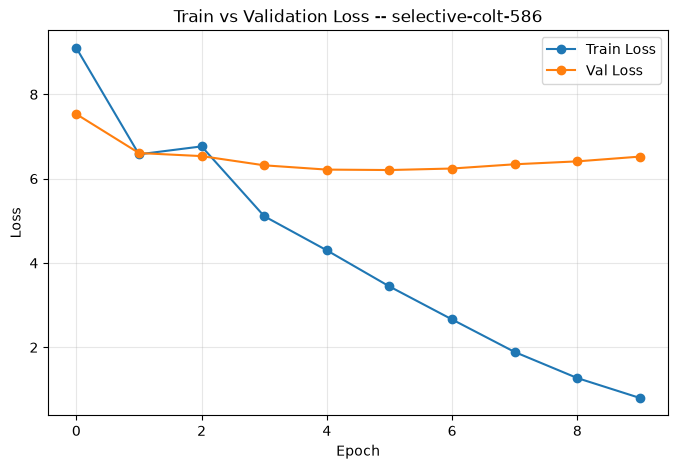

In [5]:
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="sqlite:///C:/Users/user/Documents/AI-EngineeringRoadmap/llm-from-scratch/02_tiny_llm/mlflow.db")

experiment = client.get_experiment_by_name("GPT2_Causal_LLM_with_epoch_check")

# search by the run's display name (what's shown in the UI, e.g. "selective-colt-586")
runs = client.search_runs(
    experiment.experiment_id,
    filter_string="tags.mlflow.runName = 'selective-colt-586'"
)
run_id = runs[0].info.run_id

train_history = client.get_metric_history(run_id, "train/epoch_loss")
val_history = client.get_metric_history(run_id, "val/epoch_loss")

train_epochs = [m.step for m in train_history]
train_losses = [m.value for m in train_history]
val_epochs = [m.step for m in val_history]
val_losses = [m.value for m in val_history]

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, label="Train Loss", marker="o")
plt.plot(val_epochs, val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss -- selective-colt-586")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("train_val_loss.png")
plt.show()

#### Decoding strategies to contro Randomness

In [38]:
model

GPTForCausalLM(
  (model): GPTModel(
    (tok_emb): Embedding(100, 32)
    (pos_emb): Embedding(16, 32)
    (drop_emb): Dropout(p=0.0, inplace=False)
    (trf_blocks): Sequential(
      (0): TransformerBlock(
        (attn): MultiHeadAttention(
          (W_query): Linear(in_features=32, out_features=32, bias=False)
          (W_key): Linear(in_features=32, out_features=32, bias=False)
          (W_value): Linear(in_features=32, out_features=32, bias=False)
          (out_proj): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=32, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop_shortcut): Dropout(p=0.0, inplace=False)
      )
      (1): TransformerBl

In [51]:
tokenizer = get_tokenizer()

In [52]:
print("config.vocab_size:", config.vocab_size)
print("model embedding table shape:", model.model.tok_emb.weight.shape)

config.vocab_size: 100
model embedding table shape: torch.Size([50257, 768])


In [55]:
tokenizer.decode(model.generate(
    torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length
)[0].tolist())

'Every effort moves you know to the my host, and he was "interesting, and Mrs. Gisburn had the sketch of the sketch of'

```python
import requests
from pathlib import Path

url = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-train.txt"

output_path = Path(r"C:\Users\user\Documents\AI-EngineeringRoadmap\llm-from-scratch\02_tiny_llm\data\TinyStoriesV2-GPT4-train.txt")

with requests.get(url, stream=True, timeout=60) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(
                        f"\rDownloaded: {downloaded / 1e9:.2f} GB "
                        f"({percent:.1f}%)",
                        end=""
                    )

print(f"\nSaved to: {output_path}")
```

### Temperature scaling
- Previously, we always sampled the token with the highest probability as the next token using torch.argmax
- To add variety, we can sample the next token using The torch.multinomial(probs, num_samples=1), sampling from a probability distribution
- Here, each index's chance of being picked corresponds to its probability in the input tensor
- Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:

In [1]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

In [2]:
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [3]:
import torch

In [4]:
# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probabs = torch.softmax(next_token_logits, dim=-1)
next_token_id = torch.argmax(probabs).item()
print(inverse_vocab[next_token_id])

forward


In [5]:
probabs

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [6]:
## Adding samplling using .multinomial()
torch.manual_seed(123)
next_token_id = torch.multinomial(probabs, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


- Instead of determining the most likely token via torch.argmax, we use torch.multinomial(probas, num_samples=1) to determine the most likely token by sampling from the softmax distribution
- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [7]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probabs)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- We can control the distribution and selection process via a concept called `temperature scaling`
- `Temperature scaling` is just a fancy word for dividing the logits by a number greater than 0
- Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax
- Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax

In [8]:
import matplotlib.pyplot as plt

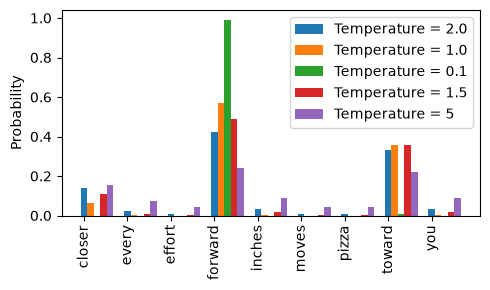

In [9]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures = [2.0, 1.0, 0.1, 1.5, 5]

scaled_probabs = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probabs[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [10]:
scaled_probabs[2]

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])

In [11]:
torch.manual_seed(123) # Testing when the value is 0.1
next_token_id = torch.multinomial(scaled_probabs[2], num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [12]:
torch.manual_seed(123) # Testing when the value is high, 5
next_token_id = torch.multinomial(scaled_probabs[-1], num_samples=1).item()
print(inverse_vocab[next_token_id])

every


In [13]:
scaled_probabs[-1]

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])

In [14]:
temperatures

[2.0, 1.0, 0.1, 1.5, 5]

In [15]:
print_sampled_tokens(scaled_probabs[2])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


Practical intuition

- `Low T (0.1–0.5)`: good for factual/deterministic tasks (code, math, QA) — you want the model's best guess reliably.
- `T = 1`: "as trained" — reflects the model's natural calibration.
- `High T (1.2–2)`: good for brainstorming, poetry, creative writing — you want exploration, even at the cost of occasional weirdness.

**One subtlety**: temperature doesn't add new information or "creativity" from nowhere — it just reweights what the model already thinks is plausible. It's not injecting randomness into meaning; it's injecting randomness into choice among things the model already considered reasonable.

### Top-K Sampling

In [16]:
next_token_logits

tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])

In [17]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print(top_logits, top_pos)

tensor([6.7500, 6.2800, 4.5100]) tensor([3, 7, 0])


In [33]:
## Zero out (set to -inf) all logits except the top-k highest values, so that a subsequent softmax+sample only considers those k tokens.
next_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other=next_token_logits
)

In [22]:
next_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [34]:
torch.softmax(next_logits, dim=-1)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

In [26]:
torch.topk(next_token_logits, top_k)

torch.return_types.topk(
values=tensor([6.7500, 6.2800, 4.5100]),
indices=tensor([3, 7, 0]))

In [28]:
next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]

tensor([False,  True,  True, False,  True,  True,  True, False,  True])

In [30]:
indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
new_logits = next_token_logits.clone()
new_logits[indices_to_remove] = float("-inf")

In [31]:
new_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [32]:
torch.softmax(new_logits, dim=0)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

In [35]:
torch.sum(torch.softmax(new_logits, dim=0))

tensor(1.)

In [71]:
top_logits, top_pos = torch.topk(next_token_logits, top_k)
filtered = torch.full_like(next_token_logits, float("-inf"))
filtered

tensor([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf])

In [72]:
filtered.scatter_(-1, top_pos, top_logits)
filtered

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [91]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond).logits
        logits = logits[:, -1, :]

        if top_k:
            top_logits, top_pos = torch.topk(logits, top_k)
            new_logits = torch.where(
                condition=logits < top_logits[:, -1],
                input=torch.tensor(float("-inf")),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break
        idx = torch.concat((idx, idx_next), dim=1)
    return tokenizer.decode(idx.squeeze().tolist())

In [92]:
tokenizer.decode(model.generate(
    torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length
)[0].tolist())

'Every effort moves you know to the my host, and he was "interesting, and Mrs. Gisburn had the sketch of the sketch of'

In [93]:
torch.manual_seed(123)
model = GPTForCausalLM.from_pretrained("checkpoints/gpt2/best")
generate(model, torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 15, config.context_length, 0.5, top_k=50)

'Every effort moves you know to the sketch of the picture--and he was dead good-rooms'

In [94]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond).logits
        logits = logits[:, -1, :]

        if top_k:
            top_logits, top_pos = torch.topk(logits, top_k)
            logits = torch.where(
                condition=logits < top_logits[:, -1],
                input=torch.tensor(float("-inf")),
                other=logits
            )

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.concat((idx, idx_next), dim=1)

    return tokenizer.decode(idx.squeeze().tolist())

In [95]:
print(generate(model, torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length, 0.5, top_k=50))

Every effort moves you know to see the do the picture--I was the fact of the house of the of the secret. Gisburn had


In [96]:
print(generate(model, torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0), 25, config.context_length))

Every effort moves you know to the my host, and he was "interesting, and Mrs. Gisburn had the sketch of the sketch of


In [70]:
model.state_dict()

OrderedDict([('model.tok_emb.weight',
              tensor([[-0.2136, -0.3778,  0.4591,  ..., -0.6136,  0.0344,  1.6389],
                      [ 0.0781,  1.1708,  0.0806,  ...,  0.3444, -1.2645,  1.2185],
                      [ 0.7141, -1.1222,  1.2525,  ..., -0.2001, -1.4497,  1.9368],
                      ...,
                      [ 1.3771, -0.7571,  1.2887,  ...,  2.2015,  0.4088, -0.0681],
                      [-1.1606,  0.6733, -2.2807,  ..., -2.1907, -0.7181, -1.2355],
                      [-0.0078,  0.8527, -1.2524,  ..., -0.2849, -0.4409,  0.7022]])),
             ('model.pos_emb.weight',
              tensor([[-0.7058,  0.4244, -0.1406,  ...,  1.8837,  1.7757, -0.4593],
                      [ 1.4980,  1.0971,  1.0844,  ..., -0.3244, -0.6371, -0.3339],
                      [-0.3276, -0.5216, -0.7107,  ..., -0.2887,  0.1800,  0.2309],
                      ...,
                      [-0.9893,  0.2357, -0.0298,  ...,  0.3724,  1.9090,  0.3741],
                      [-2.1

In [ ]:
### to save 
# torch.save(model.state_dict(), "model.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.load("model.pth", map_location=device)

### Top-p Sampling

### Beam Search

### Frequency Penalty

##### The core idea

Frequency penalty **discourages the model from repeating a word it has already said**. It looks *backward* at the sequence generated so far, counts how many times each vocab word has appeared, and subtracts a penalty proportional to that count from that word's logit before sampling the next token.

$$
\text{new\_logit}[w] = \text{logit}[w] - (\text{penalty} \times \text{count of } w \text{ so far})
$$

- A word that's appeared **0 times** — logit unchanged.
- A word that's appeared **2 times** already — logit drops by `2 × penalty`.
- Higher `penalty` = harsher punishment for repeats.

In [107]:
def apply_frequency_penalty(logits, generated_ids, penalty):
    if penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)
    return logits - penalty * counts

vocab = {"closer":0, "every":1, "effort":2, "forward":3, "inches":4, "moves":5, "pizza":6, "toward":7, "you":8}
inverse_vocab = {v: k for k, v in vocab.items()}

logits = torch.tensor([[1.0, 5.0, 2.0, 1.0, 0.5, 3.0, -1.0, 1.5, 2.5]])
generated_ids = torch.tensor([[vocab["every"], vocab["effort"], vocab["moves"], vocab["you"], vocab["every"]]])

penalized = apply_frequency_penalty(logits, generated_ids, penalty=2.0)
print(penalized)
print(inverse_vocab[penalized.argmax(dim=-1).item()])   # 'toward' instead of 'every'

tensor([[ 1.0000,  1.0000,  0.0000,  1.0000,  0.5000,  1.0000, -1.0000,  1.5000,
          0.5000]])
toward


In [110]:
inverse_vocab[logits.argmax(dim=-1).item()]

'every'

### Presence Penalty

In [112]:
def apply_presence_penalty(logits, generated_ids, penalty):
    if penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)

    presence = (counts > 0).to(logits.dtype)   # binary mask: 1.0 if seen at all, else 0.0
    return logits - penalty * presence

In [113]:
vocab = {"closer":0, "every":1, "effort":2, "forward":3, "inches":4,
         "moves":5, "pizza":6, "toward":7, "you":8}
inverse_vocab = {v: k for k, v in vocab.items()}

logits = torch.tensor([[1.0, 5.0, 2.0, 1.0, 0.5, 3.0, -1.0, 1.5, 2.5]])
generated_ids = torch.tensor([[vocab["every"], vocab["effort"], vocab["moves"], vocab["you"], vocab["every"]]])

penalized = apply_presence_penalty(logits, generated_ids, penalty=2.0)
print(penalized)
print(inverse_vocab[penalized.argmax(dim=-1).item()])

tensor([[ 1.0000,  3.0000,  0.0000,  1.0000,  0.5000,  1.0000, -1.0000,  1.5000,
          0.5000]])
every


# Frequency Penalty vs. Presence Penalty

How LLM sampling discourages repetition — the mechanics, the code, and a worked example for each.

---

## 1. Frequency Penalty

### The core idea

Frequency penalty **discourages the model from repeating a word it has already said**. It looks *backward* at the sequence generated so far, counts how many times each vocab word has appeared, and subtracts a penalty proportional to that count from that word's logit before sampling the next token.

$$
\text{new\_logit}[w] = \text{logit}[w] - (\text{penalty} \times \text{count of } w \text{ so far})
$$

- A word that's appeared **0 times** — logit unchanged.
- A word that's appeared **2 times** already — logit drops by `2 × penalty`.
- Higher `penalty` = harsher punishment for repeats. **Scales with how often a word shows up.**

### Code

```python
def apply_frequency_penalty(logits, generated_ids, penalty):
    if penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)
    return logits - penalty * counts
```

| Step | What it does |
|---|---|
| `if penalty == 0.0: return logits` | Skip counting entirely if there's no penalty to apply. |
| `counts = torch.zeros(...)` | One counter slot per vocab word, per sequence in the batch. |
| `ones = torch.ones_like(generated_ids, ...)` | The "amount to add" per occurrence — always `1`. |
| `counts.scatter_add_(-1, generated_ids, ones)` | Vectorized histogram: for every token ID in `generated_ids`, increment its counter by 1. |
| `return logits - penalty * counts` | Apply the formula above, per word. |

---

## 2. Presence Penalty

### The core idea

Presence penalty is **binary, not count-scaled**. It doesn't care *how many times* a word has appeared — only *whether* it has appeared at all.

$$
\text{new\_logit}[w] = \text{logit}[w] - \text{presence\_penalty} \times \mathbb{1}[\text{count}[w] > 0]
$$

- A word used **0 times** → no penalty.
- A word used **1 time** → full flat penalty.
- A word used **10 times** → the *same* flat penalty as if used once. **Does not scale with repeats.**

Frequency penalty punishes *how often*; presence penalty punishes *having shown up at all*.

### Code

```python
def apply_presence_penalty(logits, generated_ids, penalty):
    if penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)
    presence = (counts > 0).to(logits.dtype)   # binary mask: 1.0 if seen at all, else 0.0
    return logits - penalty * presence
```

Only one line differs from frequency penalty: `presence = (counts > 0)` collapses any nonzero count down to a flat `1.0` before applying the penalty.

---

## 3. Combining Both

### Code

```python
def apply_combined_penalty(logits, generated_ids, freq_penalty, presence_penalty):
    if freq_penalty == 0.0 and presence_penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)

    presence = (counts > 0).to(logits.dtype)
    return logits - freq_penalty * counts - presence_penalty * presence
```

Both terms are built from the **same `counts` tensor** — no need to scatter twice.

### Combined formula

$$
\text{new\_logit}[w] = \text{logit}[w] - (\text{freq\_penalty} \times \text{count}[w]) - (\text{presence\_penalty} \times \mathbb{1}[\text{count}[w] > 0])
$$

---

## 4. Worked Example

### Setup

```python
vocab = {"closer":0, "every":1, "effort":2, "forward":3, "inches":4,
         "moves":5, "pizza":6, "toward":7, "you":8}

logits = [1.0, 5.0, 2.0, 1.0, 0.5, 3.0, -1.0, 1.5, 2.5]
#   idx:   0    1    2    3    4    5    6    7    8
#  word: closer every effort forward inches moves pizza toward you

generated_ids = [every, effort, moves, you, every] → [1, 2, 5, 8, 1]
```

**Counts** derived from `generated_ids`:

| idx | 0 closer | 1 every | 2 effort | 3 forward | 4 inches | 5 moves | 6 pizza | 7 toward | 8 you |
|---|---|---|---|---|---|---|---|---|---|
| count | 0 | **2** | 1 | 0 | 0 | 1 | 0 | 0 | 1 |
| presence | 0 | **1** | 1 | 0 | 0 | 1 | 0 | 0 | 1 |

### 4.1 No penalty

Logits are returned unchanged. `argmax` → index `1` → **`"every"`** (already had the highest raw logit, and nothing discourages reusing it).

### 4.2 Frequency penalty only (`penalty = 2.0`)

| word | logit | count | 2.0×count | new_logit |
|---|---|---|---|---|
| closer | 1.0 | 0 | 0.0 | 1.0 |
| **every** | 5.0 | 2 | 4.0 | **1.0** |
| effort | 2.0 | 1 | 2.0 | 0.0 |
| forward | 1.0 | 0 | 0.0 | 1.0 |
| inches | 0.5 | 0 | 0.0 | 0.5 |
| moves | 3.0 | 1 | 2.0 | 1.0 |
| pizza | −1.0 | 0 | 0.0 | −1.0 |
| **toward** | 1.5 | 0 | 0.0 | **1.5** |
| you | 2.5 | 1 | 2.0 | 0.5 |

`argmax` → **`"toward"`**. `"every"` was hit twice as hard (used twice) and lost the lead entirely.

### 4.3 Presence penalty only (`penalty = 2.0`)

| word | logit | presence | 2.0×presence | new_logit |
|---|---|---|---|---|
| closer | 1.0 | 0 | 0.0 | 1.0 |
| **every** | 5.0 | 1 | 2.0 | **3.0** |
| effort | 2.0 | 1 | 2.0 | 0.0 |
| forward | 1.0 | 0 | 0.0 | 1.0 |
| inches | 0.5 | 0 | 0.0 | 0.5 |
| moves | 3.0 | 1 | 2.0 | 1.0 |
| pizza | −1.0 | 0 | 0.0 | −1.0 |
| toward | 1.5 | 0 | 0.0 | 1.5 |
| you | 2.5 | 1 | 2.0 | 0.5 |

`argmax` → **`"every"`** — still wins. Even though `"every"` appeared *twice*, presence penalty only ever applies the same flat `2.0` hit it would give a word used just once. `"every"`'s big head start (`5.0`) survives.

### 4.4 Combined: `freq_penalty = 1.0`, `presence_penalty = 1.0`

| word | logit | count | presence | freq term | presence term | new_logit |
|---|---|---|---|---|---|---|
| closer | 1.0 | 0 | 0 | 0.0 | 0.0 | 1.0 |
| **every** | 5.0 | 2 | 1 | 2.0 | 1.0 | **2.0** |
| effort | 2.0 | 1 | 1 | 1.0 | 1.0 | 0.0 |
| forward | 1.0 | 0 | 0 | 0.0 | 0.0 | 1.0 |
| inches | 0.5 | 0 | 0 | 0.0 | 0.0 | 0.5 |
| moves | 3.0 | 1 | 1 | 1.0 | 1.0 | 1.0 |
| pizza | −1.0 | 0 | 0 | 0.0 | 0.0 | −1.0 |
| **toward** | 1.5 | 0 | 0 | 0.0 | 0.0 | **1.5** |
| you | 2.5 | 1 | 1 | 1.0 | 1.0 | 0.5 |

`argmax` → **`"every"`** (`2.0` still beats `"toward"`'s `1.5`) — the combined penalty (`3.0` total) wasn't quite enough here.

### 4.5 Combined: `freq_penalty = 2.0`, `presence_penalty = 1.0`

| word | logit | penalty applied | new_logit |
|---|---|---|---|
| **every** | 5.0 | 2.0×2 + 1.0×1 = 5.0 | **0.0** |
| **toward** | 1.5 | 0 | **1.5** |
| effort | 2.0 | 2.0×1 + 1.0×1 = 3.0 | −1.0 |
| moves | 3.0 | 2.0×1 + 1.0×1 = 3.0 | 0.0 |
| you | 2.5 | 2.0×1 + 1.0×1 = 3.0 | −0.5 |
| forward | 1.0 | 0 | 1.0 |
| closer | 1.0 | 0 | 1.0 |
| inches | 0.5 | 0 | 0.5 |
| pizza | −1.0 | 0 | −1.0 |

`argmax` → **`"toward"`** — now the combined penalty is enough to dethrone `"every"` entirely.

---

## 5. Takeaways

| | Frequency penalty | Presence penalty |
|---|---|---|
| **What it tracks** | *How many times* a word has appeared | *Whether* a word has appeared at all |
| **Scales with repeats?** | Yes — escalating | No — flat, one-time hit |
| **Best at suppressing...** | Heavy repeaters (used many times) | Any word that's shown up, regardless of count |
| **Weak point** | None inherently, but requires bigger values for light repeaters | Can't distinguish a word used once from a word used ten times |

**Combined**, every previously-used word takes a shared flat "tax" from presence penalty, plus an extra escalating tax from frequency penalty proportional to how often it repeats. Heavy repeaters get pushed down fastest; light repeaters get a smaller nudge; words never used are untouched by either term.

This is exactly the mechanism behind OpenAI's API `frequency_penalty` and `presence_penalty` parameters — two independently tunable knobs implementing the formulas above.

In [114]:
def apply_combined_penalty(logits, generated_ids, freq_penalty, presence_penalty):
    if freq_penalty == 0.0 and presence_penalty == 0.0:
        return logits
    vocab_size = logits.size(-1)
    counts = torch.zeros(logits.size(0), vocab_size, dtype=logits.dtype)
    ones = torch.ones_like(generated_ids, dtype=logits.dtype)
    counts.scatter_add_(-1, generated_ids, ones)

    presence = (counts > 0).to(logits.dtype)
    return logits - freq_penalty * counts - presence_penalty * presence

In [117]:
vocab = {"closer":0, "every":1, "effort":2, "forward":3, "inches":4,
         "moves":5, "pizza":6, "toward":7, "you":8}
inverse_vocab = {v: k for k, v in vocab.items()}

logits = torch.tensor([[1.0, 5.0, 2.0, 1.0, 0.5, 3.0, -1.0, 1.5, 2.5]])
generated_ids = torch.tensor([[vocab["every"], vocab["effort"], vocab["moves"], vocab["you"], vocab["every"]]])

penalized = apply_combined_penalty(logits, generated_ids, 0.1, 0.2)
print(penalized)
print(inverse_vocab[penalized.argmax(dim=-1).item()])

tensor([[ 1.0000,  4.6000,  1.7000,  1.0000,  0.5000,  2.7000, -1.0000,  1.5000,
          2.2000]])
every


In [118]:
penalized = apply_combined_penalty(logits, generated_ids, freq_penalty=1.0, presence_penalty=1.0)
# every: 5.0 - (1.0×2 + 1.0×1) = 2.0 → still loses to "toward" at 1.5? No, wins by a hair

In [119]:
print(inverse_vocab[penalized.argmax(dim=-1).item()])

every


In [122]:
import torch.nn.functional as F
temperature = 0.5

probs = F.softmax(penalized / temperature, dim=-1)
next_token = torch.multinomial(probs, num_samples=1)
inverse_vocab[next_token.squeeze().item()]

'moves'

In [78]:
import os

In [80]:
sys.path.append(os.path.abspath(".."))

from sampling import sample_next_token, beam_search, _model_logits

In [103]:

import torch

def generate(
    model,
    idx,
    max_new_tokens,
    context_size,
    temperature=1.0,
    top_k=None,
    top_p=None,
    frequency_penalty=0.0,
    eos_id=None,
    greedy=False,
):
    """
    Autoregressive generation loop, routed through sample_next_token
    instead of a bare torch.argmax.

    Set greedy=True to get deterministic behavior back (useful as a
    baseline to compare every other strategy against). Otherwise
    temperature / top_k / top_p / frequency_penalty are all optional
    and compose, exactly as sample_next_token documents.
    """
    for _ in range(max_new_tokens):
        logits = _model_logits(model, idx, context_size)

        if greedy:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            next_token = sample_next_token(
                logits,
                temperature=temperature,
                top_k=top_k,
                top_p=top_p,
                frequency_penalty=frequency_penalty,
                generated_ids=idx if frequency_penalty > 0 else None,
            )

        if eos_id is not None and next_token.item() == eos_id:
            break

        idx = torch.cat((idx, next_token), dim=1)

    return idx

idx = torch.tensor(tokenizer.encode("Every effort moves you")).unsqueeze(0)
generate(model, idx, 25, config.context_length, True)

tensor([[ 6109,  3626,  6100,   345,   683,  9859,   262,   198,    40,   511,
         16356,  3465, 22037,   339, 41186,    88, 14000,    13,   812, 18727,
         24975,   465,   898, 24506,   340,   502,   587,  1165,   290]])

In [106]:
print(tokenizer.decode(
    generate(model, idx, 25, config.context_length, top_k=50).squeeze(0).tolist()
))

Every effort moves you know to put him--the: " I he had been his painting; he was with the house of the donkey. I
